# Willett-Style Supervised S5 Baseline

This notebook keeps the supervised Willett reconstruction pipeline intact and swaps only the sequence decoder backbone from GRU to S5. The point is to test whether a standalone S5 decoder can learn the Brain2Text24 supervised CTC task before using S5 inside POSSM/SSL experiments.

In [3]:
# Mount Google Drive when running in Colab.

try:
    from google.colab import drive  # type: ignore
except Exception:
    drive = None

if drive is not None:
    drive.mount('/content/drive')
else:
    print('Not running in Colab; skipping Drive mount.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Repo import bootstrap (Colab).

from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

REPO_URL = 'https://github.com/ethan-read/utah-ssl.git'
REPO_DIR = Path('/content/utah-ssl')
EXPERIMENTS_DIR = REPO_DIR / 'analysis' / 'active' / 'ssl_experiments'
S5_DIR = REPO_DIR / 'analysis' / 'active' / 'transfer_benchmark' / 'ssl_autoresearch'
WILLETT_DIR = EXPERIMENTS_DIR / 'willett_reconstruction'

os.chdir('/content')
if REPO_DIR.exists():
    print('Using existing repo:', REPO_DIR)
    try:
        repo_status = subprocess.run(
            ['git', '-C', str(REPO_DIR), 'status', '--porcelain'],
            check=True,
            capture_output=True,
            text=True,
        )
        if repo_status.stdout.strip():
            print('Skipping auto-pull because the Colab checkout has local changes.')
        else:
            subprocess.run(
                ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', 'main'],
                check=True,
            )
            print('Updated existing repo checkout from origin/main.')
    except Exception as exc:
        print('warning: could not auto-update existing repo checkout:', exc)
else:
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
for path in (REPO_DIR, EXPERIMENTS_DIR, S5_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

if not WILLETT_DIR.exists():
    raise FileNotFoundError('Missing Willett helper package in cloned repo checkout.')

DRIVE_ROOT = Path('/content/drive/MyDrive')
CACHE_ROOT = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1'
OUTPUT_ROOT = DRIVE_ROOT / 'utah_ssl' / 'outputs' / 'willett_s5_reconstruction'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('cwd:', Path.cwd())
print('willett_reconstruction dir exists:', WILLETT_DIR.exists(), WILLETT_DIR)
print('CACHE_ROOT:', CACHE_ROOT)
print('CACHE_ROOT exists:', CACHE_ROOT.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)


cwd: /content/utah-ssl
willett_reconstruction dir exists: True /content/utah-ssl/analysis/active/ssl_experiments/willett_reconstruction
CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
CACHE_ROOT exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/willett_s5_reconstruction


In [5]:
# Imports.

import matplotlib.pyplot as plt
import pandas as pd

from recompute_split_feature_stats import resolve_precomputed_split_stats_path
from willett_reconstruction.reporting import display_willett_report
from willett_reconstruction.train import WillettReconstructionConfig, run_willett_reconstruction

def timestamp_utc() -> str:
    return datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')


In [6]:
# Run configuration.

DATASET = 'brain2text24'
FEATURE_MODE = 'tx_sbp'
BOUNDARY_KEY_MODE = 'session'
NORMALIZATION_MODE = 'global'

RUN_ACTION = 'fresh'  # one of {'fresh', 'resume_latest', 'skip'}
RUN_NAME = None  # set an existing run name when RUN_ACTION='resume_latest'
MAX_STEPS = 60000

# Keep Willett-style supervised temporal patching.
PATCH_SIZE = 14
PATCH_STRIDE = 4
INPUT_PROJECTION_SIZE = 256
INPUT_PROJECTION_DROPOUT = 0.2
SESSION_ADAPTER_ENABLED = True

# S5 backbone under the same supervised CTC surface.
S5_HIDDEN_SIZE = 512
S5_STATE_SIZE = 128
S5_NUM_LAYERS = 5
S5_DROPOUT = 0.2
S5_DIRECTION = 'causal'  # use 'bidirectional' only as an offline upper bound
S5_FFN_MULTIPLIER = 2.0

# The data recipe matches the successful supervised Willett baseline.
INPUT_SMOOTHING_SIGMA_BINS = 2.0
INPUT_SMOOTHING_KERNEL_SIZE = 100
INPUT_SMOOTHING_THRESHOLD = 0.01
WHITE_NOISE_SD = 1.0
CONSTANT_OFFSET_SD = 0.2

# Presets: 's5_safe' is a conservative S5 optimizer; 'gru_matched' mirrors the GRU baseline optimizer.
OPTIMIZER_PRESET = 's5_safe'  # one of {'s5_safe', 'gru_matched'}
if OPTIMIZER_PRESET == 's5_safe':
    LEARNING_RATE = 1e-3
    MIN_LEARNING_RATE = 1e-5
    WARMUP_STEPS = 1000
    WEIGHT_DECAY = 1e-5
    ADAM_EPSILON = 1e-8
    MAX_GRAD_NORM = 10.0
elif OPTIMIZER_PRESET == 'gru_matched':
    LEARNING_RATE = 1e-2
    MIN_LEARNING_RATE = 1e-4
    WARMUP_STEPS = 1000
    WEIGHT_DECAY = 1e-5
    ADAM_EPSILON = 1e-1
    MAX_GRAD_NORM = 10.0
else:
    raise ValueError("OPTIMIZER_PRESET must be one of {'s5_safe', 'gru_matched'}")

BATCH_SIZE = 64
VAL_EVERY_STEPS = 100
CHECKPOINT_EVERY_STEPS = 500
CHECKPOINT_KEEP_LAST = 2
PROGRESS_EVERY_STEPS = 25
SEED = 7

print({
    'RUN_ACTION': RUN_ACTION,
    'MAX_STEPS': MAX_STEPS,
    'OPTIMIZER_PRESET': OPTIMIZER_PRESET,
    'decoder_backbone_type': 's5',
    's5_hidden_size': S5_HIDDEN_SIZE,
    's5_state_size': S5_STATE_SIZE,
    's5_num_layers': S5_NUM_LAYERS,
    's5_dropout': S5_DROPOUT,
    'learning_rate': LEARNING_RATE,
    'adam_epsilon': ADAM_EPSILON,
})


{'RUN_ACTION': 'fresh', 'MAX_STEPS': 60000, 'OPTIMIZER_PRESET': 's5_safe', 'decoder_backbone_type': 's5', 's5_hidden_size': 512, 's5_state_size': 128, 's5_num_layers': 5, 's5_dropout': 0.2, 'learning_rate': 0.001, 'adam_epsilon': 1e-08}


In [7]:
# Reuse or recompute the canonical raw split stats for this supervised baseline.

FORCE_RECOMPUTE_STATS = False

def run_stats_command(label: str, cmd: list[str]) -> None:
    print(f'Running {label}:', ' '.join(str(part) for part in cmd))
    result = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True, capture_output=True)
    print(f'{label} returncode:', result.returncode)
    if result.stdout:
        print(f'\n{label} STDOUT\n')
        print(result.stdout)
    if result.stderr:
        print(f'\n{label} STDERR\n')
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f'{label} recompute failed.')

def print_metadata(path: Path) -> None:
    metadata_path = Path(path).with_suffix('.json')
    print('artifact:', path)
    print('sidecar:', metadata_path)
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        preview_keys = ['kind', 'source_cache_variant', 'dataset', 'feature_mode', 'boundary_key_mode', 'feature_dim', 'feature_policy']
        print(json.dumps({key: metadata.get(key) for key in preview_keys if key in metadata}, indent=2))

if not CACHE_ROOT.exists():
    raise FileNotFoundError(f'Cache root not found: {CACHE_ROOT}')

SPLIT_STATS_PATH = resolve_precomputed_split_stats_path(
    cache_root=CACHE_ROOT,
    dataset=DATASET,
    train_split_name='competition_train',
    feature_mode=FEATURE_MODE,
    preferred_path=None,
)
stats_sidecar = SPLIT_STATS_PATH.with_suffix('.json')
if FORCE_RECOMPUTE_STATS or not (SPLIT_STATS_PATH.exists() and stats_sidecar.exists()):
    cmd = [
        sys.executable,
        str(EXPERIMENTS_DIR / 'recompute_split_feature_stats.py'),
        '--cache-root', str(CACHE_ROOT),
        '--dataset', DATASET,
        '--feature-mode', FEATURE_MODE,
        '--boundary-key-mode', BOUNDARY_KEY_MODE,
        '--output-path', str(SPLIT_STATS_PATH),
        '--overwrite',
    ]
    run_stats_command('willett_s5_split_stats', cmd)
else:
    print('Reusing existing split stats.')
print_metadata(SPLIT_STATS_PATH)


Reusing existing split stats.
artifact: /content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/raw/brain2text24/competition_train/tx_only/global_v1.pt
sidecar: /content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/raw/brain2text24/competition_train/tx_only/global_v1.json
{
  "kind": "split_feature_stats",
  "source_cache_variant": "raw",
  "dataset": "brain2text24",
  "feature_mode": "tx_only",
  "boundary_key_mode": "session",
  "feature_dim": 128,
  "feature_policy": "area6v_v1"
}


In [8]:
# Run or resume the supervised S5 baseline.

RUN_SUMMARY = None

if RUN_ACTION == 'skip':
    print('Skipping supervised S5 run.')
else:
    resolved_run_name = RUN_NAME
    if RUN_ACTION == 'resume_latest' and resolved_run_name is None:
        run_prefix = f'willett_s5_{FEATURE_MODE}_{S5_DIRECTION}_'
        candidates = sorted(
            [path for path in OUTPUT_ROOT.glob(f'{run_prefix}*') if path.is_dir()],
            key=lambda path: path.stat().st_mtime,
        )
        if not candidates:
            raise FileNotFoundError(f'No existing supervised S5 runs found under {OUTPUT_ROOT} with prefix {run_prefix!r}.')
        resolved_run_name = candidates[-1].name
        print('resuming latest run:', resolved_run_name)
    elif resolved_run_name is None:
        resolved_run_name = f'willett_s5_{FEATURE_MODE}_{S5_DIRECTION}_{timestamp_utc()}'
    config = WillettReconstructionConfig(
        seed=SEED,
        dataset=DATASET,
        feature_mode=FEATURE_MODE,
        boundary_key_mode=BOUNDARY_KEY_MODE,
        normalization_mode=NORMALIZATION_MODE,
        batch_size=BATCH_SIZE,
        max_steps=MAX_STEPS,
        learning_rate=LEARNING_RATE,
        min_learning_rate=MIN_LEARNING_RATE,
        warmup_steps=WARMUP_STEPS,
        weight_decay=WEIGHT_DECAY,
        adam_epsilon=ADAM_EPSILON,
        max_grad_norm=MAX_GRAD_NORM,
        val_every_steps=VAL_EVERY_STEPS,
        checkpoint_every_steps=CHECKPOINT_EVERY_STEPS,
        checkpoint_keep_last=CHECKPOINT_KEEP_LAST,
        progress_every_steps=PROGRESS_EVERY_STEPS,
        input_projection_size=INPUT_PROJECTION_SIZE,
        input_projection_dropout=INPUT_PROJECTION_DROPOUT,
        decoder_backbone_type='s5',
        s5_hidden_size=S5_HIDDEN_SIZE,
        s5_state_size=S5_STATE_SIZE,
        s5_num_layers=S5_NUM_LAYERS,
        s5_dropout=S5_DROPOUT,
        s5_direction=S5_DIRECTION,
        s5_ffn_multiplier=S5_FFN_MULTIPLIER,
        patch_size=PATCH_SIZE,
        patch_stride=PATCH_STRIDE,
        session_adapter_enabled=SESSION_ADAPTER_ENABLED,
        input_smoothing_sigma_bins=INPUT_SMOOTHING_SIGMA_BINS,
        input_smoothing_kernel_size=INPUT_SMOOTHING_KERNEL_SIZE,
        input_smoothing_threshold=INPUT_SMOOTHING_THRESHOLD,
        white_noise_sd=WHITE_NOISE_SD,
        constant_offset_sd=CONSTANT_OFFSET_SD,
        precomputed_split_stats_path=SPLIT_STATS_PATH,
        output_root=OUTPUT_ROOT,
        run_name=resolved_run_name,
        cache_root=CACHE_ROOT,
        resume_latest=(RUN_ACTION == 'resume_latest'),
    )
    print(config)
    t0 = time.perf_counter()
    RUN_SUMMARY = run_willett_reconstruction(config)
    print('elapsed_s:', round(time.perf_counter() - t0, 1))
    print('run_dir:', RUN_SUMMARY['run_dir'])
    print('best_step:', RUN_SUMMARY.get('best_step'))
    print('metrics:', json.dumps(RUN_SUMMARY.get('metrics', {}), indent=2))


WillettReconstructionConfig(seed=7, dataset='brain2text24', feature_mode='tx_only', boundary_key_mode='session', normalization_mode='global', batch_size=64, max_steps=12000, learning_rate=0.001, min_learning_rate=1e-05, warmup_steps=1000, weight_decay=1e-05, adam_epsilon=1e-08, max_grad_norm=10.0, val_every_steps=100, checkpoint_every_steps=500, checkpoint_keep_last=2, progress_every_steps=25, input_projection_size=256, input_projection_dropout=0.2, decoder_backbone_type='s5', gru_hidden_size=512, gru_num_layers=5, gru_dropout=0.4, s5_hidden_size=512, s5_state_size=128, s5_num_layers=5, s5_dropout=0.2, s5_direction='causal', s5_ffn_multiplier=2.0, patch_size=14, patch_stride=4, session_adapter_enabled=True, input_smoothing_sigma_bins=2.0, input_smoothing_kernel_size=100, input_smoothing_threshold=0.01, white_noise_sd=1.0, constant_offset_sd=0.2, precomputed_split_stats_path=PosixPath('/content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/raw/brain2text24/competition_train/tx_o

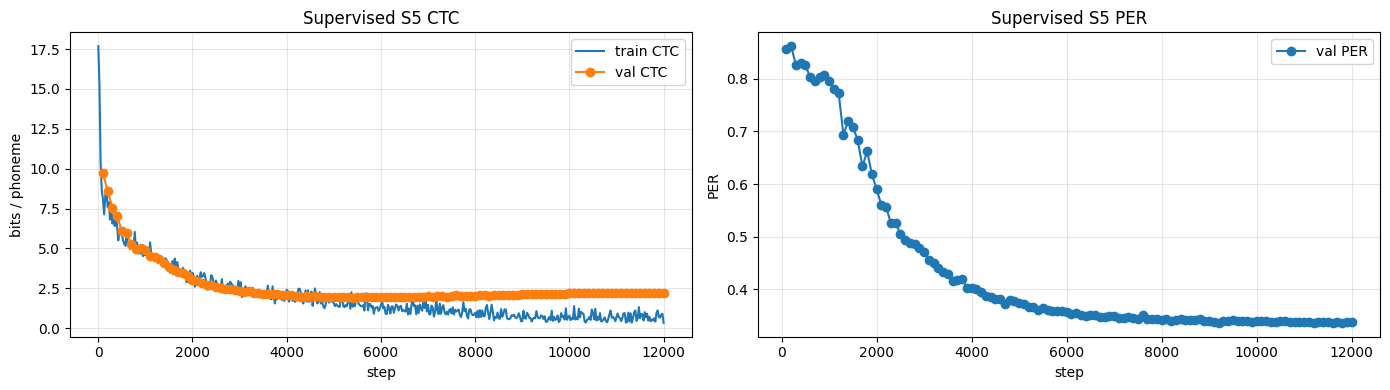

,step,val_ctc_bpphone,val_phoneme_error_rate,best_val_ctc_bpphone,best_val_phoneme_error_rate
555,11100,2.192568,0.337159,1.894954,0.336498
560,11200,2.192751,0.336375,1.894954,0.336375
565,11300,2.195169,0.337737,1.894954,0.336375
570,11400,2.195859,0.337200,1.894954,0.336375
575,11500,2.193390,0.337365,1.894954,0.336375
580,11600,2.194498,0.336787,1.894954,0.336375
585,11700,2.194510,0.337530,1.894954,0.336375
590,11800,2.195013,0.336911,1.894954,0.336375
595,11900,2.195695,0.338150,1.894954,0.336375
600,12000,2.197175,0.337324,1.894954,0.336375


In [9]:
# Plot convergence diagnostics.

if RUN_SUMMARY is None:
    raise ValueError('RUN_SUMMARY is empty. Run the supervised S5 baseline cell first.')

report = display_willett_report(RUN_SUMMARY)
progress_df = report['progress_df']
train_df = report['train_df']
val_df = report['val_df']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if not train_df.empty and 'step' in train_df and 'train_ctc_bpphone' in train_df:
    axes[0].plot(train_df['step'], train_df['train_ctc_bpphone'], label='train CTC')
if not val_df.empty and 'step' in val_df and 'val_ctc_bpphone' in val_df:
    axes[0].plot(val_df['step'], val_df['val_ctc_bpphone'], marker='o', label='val CTC')
axes[0].set_title('Supervised S5 CTC')
axes[0].set_xlabel('step')
axes[0].set_ylabel('bits / phoneme')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if not val_df.empty and 'step' in val_df and 'val_phoneme_error_rate' in val_df:
    axes[1].plot(val_df['step'], val_df['val_phoneme_error_rate'], marker='o', label='val PER')
axes[1].set_title('Supervised S5 PER')
axes[1].set_xlabel('step')
axes[1].set_ylabel('PER')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if not val_df.empty:
    cols = [
        'step',
        'val_ctc_bpphone',
        'val_phoneme_error_rate',
        'best_val_ctc_bpphone',
        'best_val_phoneme_error_rate',
    ]
    display(val_df[[col for col in cols if col in val_df.columns]].tail(10))


In [10]:
from google.colab import runtime
runtime.unassign()